# Level 2 – Task 1
## Table Booking and Online Delivery Analysis

**Objective:**
- Determine the percentage of restaurants offering table booking.
- Determine the percentage of restaurants offering online delivery.
- Compare average ratings of restaurants with and without table booking.
- Analyze online delivery availability across different price ranges.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../Outputs/zomato_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (9551, 21)


# Inspect columns

In [3]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [4]:
required_columns = [
    "Has Table booking",
    "Has Online delivery",
    "Aggregate rating",
    "Price range"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:")
    print(missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [5]:
print("Table Booking values:")
print(df["Has Table booking"].value_counts())

print("\nOnline Delivery values:")
print(df["Has Online delivery"].value_counts())

print("\nPrice Range values:")
print(df["Price range"].value_counts().sort_index())

Table Booking values:
Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64

Online Delivery values:
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Price Range values:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


# Percentage of restaurants offering Table Booking

In [6]:
table_booking_counts = df["Has Table booking"].value_counts()

table_booking_percentage = (
    table_booking_counts / len(df) * 100
).round(2)

print("Table Booking Percentage:")
print(table_booking_percentage)

Table Booking Percentage:
Has Table booking
No     87.88
Yes    12.12
Name: count, dtype: float64


# Percentage of restaurants offering Online Delivery

In [7]:
online_delivery_counts = df["Has Online delivery"].value_counts()

online_delivery_percentage = (
    online_delivery_counts / len(df) * 100
).round(2)

print("Online Delivery Percentage:")
print(online_delivery_percentage)

Online Delivery Percentage:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


In [8]:
service_summary = pd.DataFrame({
    "Service": ["Table Booking", "Online Delivery"],
    "Yes Percentage": [
        table_booking_percentage.get("Yes", 0),
        online_delivery_percentage.get("Yes", 0)
    ],
    "No Percentage": [
        table_booking_percentage.get("No", 0),
        online_delivery_percentage.get("No", 0)
    ]
})

service_summary

,Service,Yes Percentage,No Percentage
0,Table Booking,12.12,87.88
1,Online Delivery,25.66,74.34


# Visualize service availability

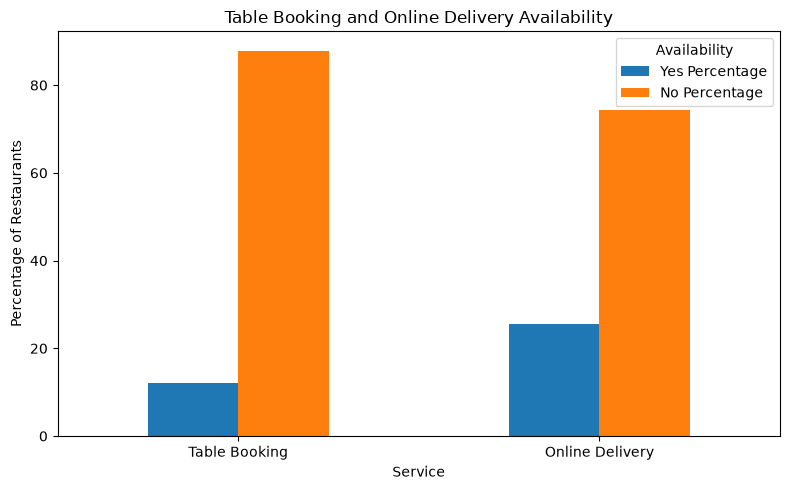

In [9]:
service_plot = service_summary.set_index("Service")

service_plot[["Yes Percentage", "No Percentage"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Table Booking and Online Delivery Availability")
plt.xlabel("Service")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Availability")
plt.tight_layout()
plt.show()

# Average rating with vs. without Table Booking

In [10]:
booking_rating = (
    df.groupby("Has Table booking")["Aggregate rating"]
    .mean()
    .round(2)
)

print("Average Aggregate Rating by Table Booking:")
print(booking_rating)

Average Aggregate Rating by Table Booking:
Has Table booking
No     2.56
Yes    3.44
Name: Aggregate rating, dtype: float64


# Visualize the rating comparison

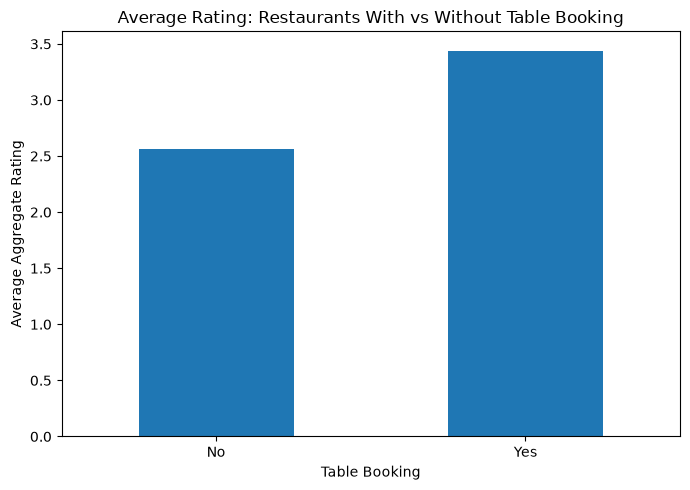

In [11]:
plt.figure(figsize=(7, 5))

booking_rating.plot(kind="bar")

plt.title("Average Rating: Restaurants With vs Without Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Online Delivery by Price Range

In [12]:
delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

delivery_price = delivery_price.round(2)

print("Online Delivery Availability by Price Range (%):")
display(delivery_price)

Online Delivery Availability by Price Range (%):


Has Online delivery,No,Yes
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


# Visualize Online Delivery by Price Range

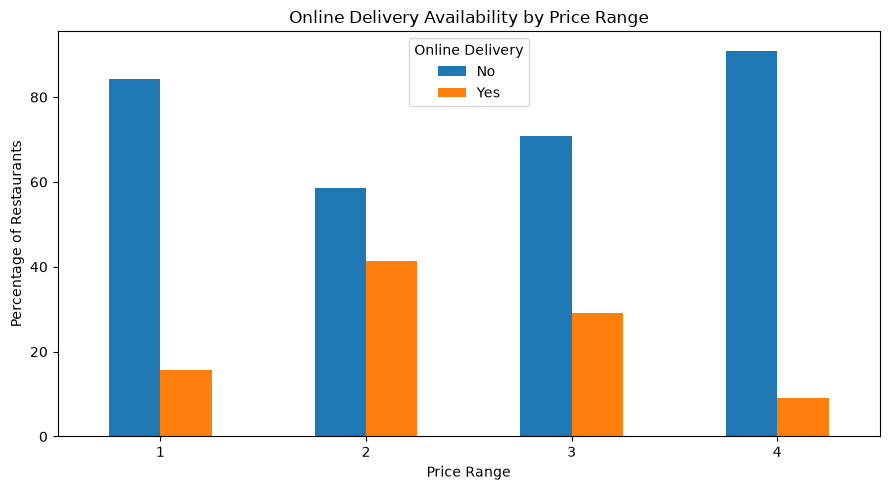

In [13]:
delivery_price.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery")
plt.tight_layout()
plt.show()

# outputs

In [14]:
service_summary.to_csv(
    "../Outputs/table_booking_online_delivery_percentage.csv",
    index=False
)

booking_rating.reset_index().to_csv(
    "../Outputs/booking_rating_comparison.csv",
    index=False
)

delivery_price.reset_index().to_csv(
    "../Outputs/delivery_by_price_range.csv",
    index=False
)

print("All Task 1 outputs saved successfully.")

All Task 1 outputs saved successfully.


# Conclusion

The analysis examined table booking and online delivery availability across restaurants.

- The percentage of restaurants offering table booking was calculated.
- The percentage of restaurants offering online delivery was calculated.
- Average Aggregate Ratings were compared between restaurants with and without table booking.
- Online delivery availability was analyzed across different price ranges.
- Visualizations were created to clearly communicate the findings.

These results provide insights into the relationship between restaurant services, pricing, and customer ratings.